<a href="https://colab.research.google.com/github/2023-105670/Bayesian-Statistics/blob/main/March_13_Act.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("/content/supervised_dataset.csv")

le = LabelEncoder()
data["Final_Grade"] = le.fit_transform(data["Final_Grade"])

X = data[['Study_Hours', 'Attendance_%', 'Assignments_Submitted']]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         3
        Pass       1.00      1.00      1.00        13

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



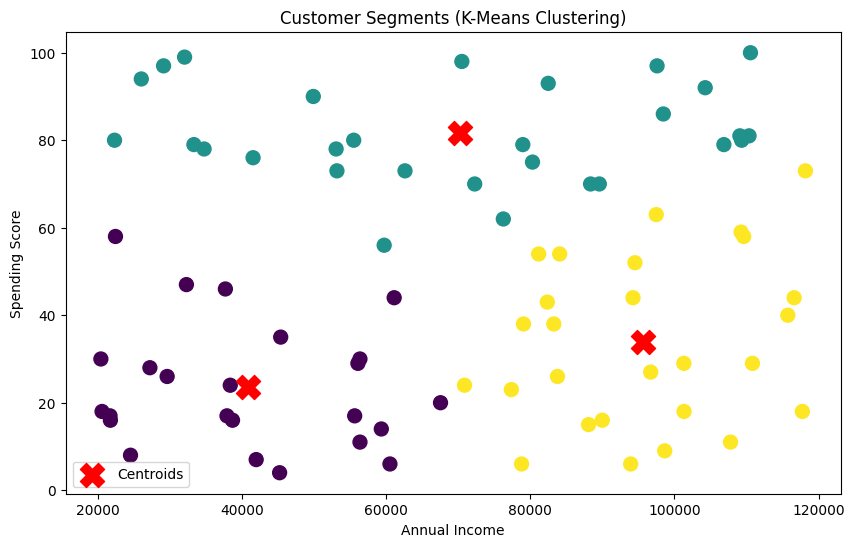

First 5 rows with cluster assignments:
   Age  Annual_Income  Spending_Score  Cluster
0   27          70864              24        2
1   46          55621              17        0
2   53         110555             100        1
3   33         109328              80        1
4   20          37895              17        0


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('/content/unsupervised_dataset.csv')

X = data[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_init=10, n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(data['Annual_Income'], data['Spending_Score'], c=data['Cluster'], cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0] * scaler.scale_[0] + scaler.mean_[0],
            kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],
            s=300, c='red', marker='X', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

print("First 5 rows with cluster assignments:")
print(data.head())